# Домашнее задание 1. Постановка и классификация задач, МНК, LP

**Выдано:** 9 сентября 2026. **Срок сдачи:** 23 сентября 2026 (до начала занятия). **Максимум:** 10 баллов (+1 бонус).

**Как сдавать.** Заполните этот ноутбук (ответы на теоретические вопросы — в markdown-ячейках, формулы в $\LaTeX$; код — в code-ячейках), выполните целиком (`Kernel → Restart Kernel and Run All Cells`) и сдайте через pull request: файл `submissions/hw01/<фамилия>.ipynb`, инструкция — [`CONTRIBUTING.md`](../CONTRIBUTING.md). Задачи можно обсуждать, но текст и код пишутся самостоятельно.

**Материал:** лекция 1 ([конспект](../lectures/lecture01/lecture01.md), [демо](../lectures/lecture01/demo01.ipynb)). Ничего сверх лекции не требуется.

Запуск: `uv sync` в корне репозитория, затем `uv run jupyter lab`.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import linprog, minimize

rng = np.random.default_rng(2026)   # не меняйте seed: данные должны совпадать у всех

## Задача 1. Классификация (4 балла)

Для каждой задачи (а)–(г) запишите её в стандартной форме

$$\min_x f(x) \quad\text{при}\quad g(x) = 0,\; h(x) \ge 0,$$

явно указав, что такое $x$ (и его размерность), $f$, $g$, $h$. Затем определите класс: LP / QP / QCQP / NLP; с ограничениями или без; выпуклая или нет (обоснуйте там, где это очевидно). По 1 баллу за пункт.

**(а)** Найти точку прямой $\{x \in \mathbb{R}^3 : x_1 + x_2 + x_3 = 1,\; x_1 - x_3 = 0\}$, ближайшую к точке $(1, 2, 3)$. *Дополнительно:* найдите эту точку (руками или численно).

**(б)** Диета: $n$ продуктов с ценами $c_j$; $m$ питательных веществ, продукт $j$ содержит $A_{ij}$ единиц вещества $i$. Купить продукты минимальной стоимости так, чтобы каждого вещества было не меньше $b_i$.

**(в)** Найти вписанный в единичный круг прямоугольник наибольшей площади (стороны параллельны осям).

**(г)** Подогнать модель $\varphi(t; x) = x_1 \sin(x_2 t + x_3)$ к измерениям $(t_i, y_i)$, $i = 1, \dots, N$, по критерию суммы квадратов невязок.

**(д, бонус +1)** $\min_{x \in \mathbb{R}^n} \max_i |a_i^\top x - b_i|$ (подгонка в чебышёвской норме). Переформулируйте как гладкую задачу с одной дополнительной переменной, по образцу переформулировки из раздела 8 лекции. Какой это класс?

**(а)**

**Ответ.** Переменная решения — точка $x=(x_1,x_2,x_3)\in\mathbb R^3$. Чтобы не работать с корнем, минимизируем половину квадрата расстояния до $p=(1,2,3)$:

$$
f(x)=\frac12\|x-p\|_2^2,
\qquad
g(x)=\begin{pmatrix}x_1+x_2+x_3-1\\x_1-x_3\end{pmatrix}=0,
$$

а неравенств $h$ нет. Это QP с двумя линейными ограничениями-равенствами. Гессиан цели равен единичной матрице, то есть положительно определён, а допустимое множество аффинно; следовательно, задача выпуклая (даже строго выпуклая по цели) и решение единственно.

Из ограничений $x_1=x_3=a$ и $x_2=1-2a$. После подстановки квадрат расстояния равен

$$
(a-1)^2+(-1-2a)^2+(a-3)^2=6a^2-4a+11.
$$

Его производная $12a-4$ обращается в ноль при $a=1/3$. Поэтому ближайшая точка:

$$x^*=\left(\frac13,\frac13,\frac13\right).$$

In [2]:
# Численная проверка через условия оптимальности для квадратичной задачи
p = np.array([1.0, 2.0, 3.0])
C = np.array([[1.0, 1.0, 1.0],
              [1.0, 0.0, -1.0]])
d = np.array([1.0, 0.0])

KKT = np.block([[np.eye(3), C.T],
                [C, np.zeros((2, 2))]])
rhs = np.concatenate([p, d])
x_star = np.linalg.solve(KKT, rhs)[:3]

print("x* =", x_star)
print("g(x*) =", C @ x_star - d)
print("расстояние =", np.linalg.norm(x_star - p))

x* = [0.33333333 0.33333333 0.33333333]
g(x*) = [-2.22044605e-16  0.00000000e+00]
расстояние = 3.214550253664319


**(б)**

**Ответ.** Пусть $x_j\ge 0$ — количество продукта $j$, а $x=(x_1,\ldots,x_n)\in\mathbb R^n$. Тогда стоимость покупки равна $c^\top x$, а количество всех питательных веществ — вектору $Ax\in\mathbb R^m$. Стандартная форма:

$$
\min_{x\in\mathbb R^n} f(x)=c^\top x,
\qquad g(x)\text{ отсутствует},
\qquad
h(x)=\begin{pmatrix}Ax-b\\x\end{pmatrix}\ge0.
$$

Цель и все ограничения линейны, поэтому это LP с линейными неравенствами. Допустимое множество является пересечением полупространств и потому выпукло; линейная цель также выпукла, следовательно, задача выпуклая.

**(в)**

**Ответ.** Обозначим через $u\ge0$ и $v\ge0$ половины горизонтальной и вертикальной сторон прямоугольника. Его вершины имеют координаты $(\pm u,\pm v)$, площадь равна $4uv$, а условие нахождения вершин в единичном круге имеет вид $u^2+v^2\le1$. Получаем

$$
\min_{(u,v)\in\mathbb R^2} f(u,v)=-4uv,
\qquad g(u,v)\text{ отсутствует},
$$

$$
h(u,v)=\begin{pmatrix}1-u^2-v^2\\u\\v\end{pmatrix}\ge0.
$$

Цель квадратичная и присутствует квадратичное ограничение, поэтому это QCQP с неравенствами. Допустимая четверть круга выпукла, но гессиан цели

$$
\nabla^2 f=\begin{pmatrix}0&-4\\-4&0\end{pmatrix}
$$

имеет собственные числа $-4$ и $4$ и не является положительно полуопределённым. Следовательно, данная формулировка задачи невыпуклая.

**(г)**

**Ответ.** Переменная решения — вектор параметров $x=(x_1,x_2,x_3)\in\mathbb R^3$. Введём невязки

$$r_i(x)=x_1\sin(x_2t_i+x_3)-y_i.$$

Стандартная форма задачи:

$$
\min_{x\in\mathbb R^3} f(x)=\frac12\sum_{i=1}^{N}r_i(x)^2,
\qquad g(x)\text{ отсутствует},\qquad h(x)\text{ отсутствует}.
$$

Это безусловная NLP со структурой нелинейного метода наименьших квадратов. В отличие от линейного МНК, модель нелинейно зависит от параметров $x_2$ и $x_3$, поэтому цель не является квадратичной функцией параметров. В общем случае задача невыпуклая: периодичность синуса создаёт несколько локальных минимумов.

**(д, бонус)**

**Ответ.** Введём одну дополнительную переменную $s\in\mathbb R$, которая ограничивает сверху модуль каждой невязки. Для $z=(x,s)\in\mathbb R^{n+1}$ получаем

$$
\min_{x,s} s
$$

при ограничениях для всех $i$:

$$
s-(a_i^\top x-b_i)\ge0,
\qquad
s+(a_i^\top x-b_i)\ge0.
$$

То есть $g$ отсутствует, а $h(z)$ состоит из перечисленных $2m$ линейных функций (где $m$ — число невязок). Эти две группы неравенств эквивалентны $s\ge|a_i^\top x-b_i|$; отдельное условие $s\ge0$ не требуется, так как оно уже следует из любой такой пары. Цель и ограничения линейны, поэтому получилась выпуклая LP.

## Задача 2. Практика (6 баллов)

**(а) Линейный МНК и переобучение (3 балла).** Ниже сгенерированы обучающая и тестовая выборки: $y = \sin(2\pi t) + \varepsilon$, $\varepsilon \sim \mathcal{N}(0, 0.1^2)$. Для каждой степени $d = 1, \dots, 15$ подгоните полином $\varphi(t; x) = x_0 + x_1 t + \dots + x_d t^d$ методом наименьших квадратов (`numpy.linalg.lstsq`; матрицу $A$ удобно строить через `np.vander(t, d + 1, increasing=True)`). Постройте график зависимости среднеквадратичной ошибки на обучающей и на тестовой выборках от $d$ (ось $y$ — логарифмическая). Объясните поведение обеих кривых в двух-трёх предложениях: почему одна монотонна, а другая нет?

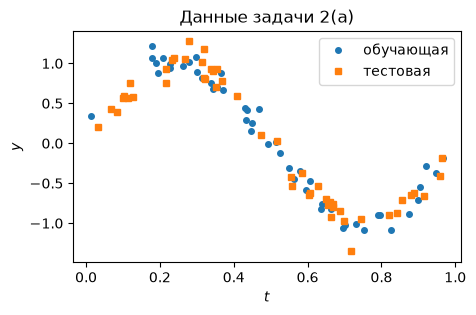

In [3]:
N = 50
t_train = np.sort(rng.uniform(0, 1, N))
y_train = np.sin(2 * np.pi * t_train) + 0.1 * rng.standard_normal(N)
t_test = np.sort(rng.uniform(0, 1, N))
y_test = np.sin(2 * np.pi * t_test) + 0.1 * rng.standard_normal(N)

plt.figure(figsize=(5, 3))
plt.plot(t_train, y_train, "o", ms=4, label="обучающая")
plt.plot(t_test, y_test, "s", ms=4, label="тестовая")
plt.legend(); plt.xlabel("$t$"); plt.ylabel("$y$"); plt.title("Данные задачи 2(а)")
plt.show()

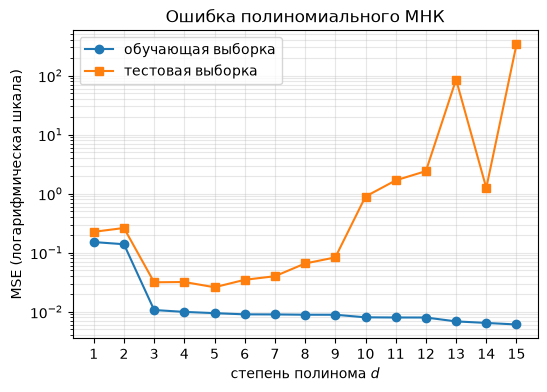

Лучшая степень по тестовой MSE: 5
Минимальная тестовая MSE: 0.025973432493711413
Обучающая MSE при d=15: 0.006077077988950282


In [4]:
degrees = np.arange(1, 16)
train_mse = []
test_mse = []

for d in degrees:
    A_train = np.vander(t_train, d + 1, increasing=True)
    A_test = np.vander(t_test, d + 1, increasing=True)
    coef, *_ = np.linalg.lstsq(A_train, y_train, rcond=None)

    train_mse.append(np.mean((A_train @ coef - y_train) ** 2))
    test_mse.append(np.mean((A_test @ coef - y_test) ** 2))

train_mse = np.array(train_mse)
test_mse = np.array(test_mse)

plt.figure(figsize=(6, 4))
plt.semilogy(degrees, train_mse, "o-", label="обучающая выборка")
plt.semilogy(degrees, test_mse, "s-", label="тестовая выборка")
plt.xticks(degrees)
plt.xlabel("степень полинома $d$")
plt.ylabel("MSE (логарифмическая шкала)")
plt.title("Ошибка полиномиального МНК")
plt.grid(True, which="both", alpha=0.3)
plt.legend()
plt.show()

best_degree = degrees[np.argmin(test_mse)]
print("Лучшая степень по тестовой MSE:", best_degree)
print("Минимальная тестовая MSE:", test_mse.min())
print("Обучающая MSE при d=15:", train_mse[-1])

**Ответ.** Обучающая ошибка не возрастает с увеличением степени, потому что пространство полиномов степени $d$ вложено в пространство полиномов степени $d+1$: новая модель всегда может воспроизвести старую, положив дополнительный коэффициент равным нулю. Тестовая ошибка сначала уменьшается и достигает минимума при $d=5$, а затем в целом растёт: полином высокой степени начинает подгонять случайный шум обучающей выборки, его коэффициенты становятся чувствительными к данным и обобщающая способность ухудшается — это переобучение.

**(б) LP: диета (3 балла).** Решите задачу диеты из 1(б) с помощью `scipy.optimize.linprog` для данных ниже (4 продукта, 3 вещества). Выведите оптимальное $x$ и стоимость. Определите, какие из ограничений $Ax \ge b$ и $x \ge 0$ **активны** в решении (невязка равна нулю с точностью $10^{-9}$). Затем увеличьте требование по первому веществу на единицу ($b_1 \to b_1 + 1$), решите заново и сравните: как изменились решение и стоимость? Изменился ли набор активных ограничений?

Подсказка: `linprog` минимизирует $c^\top x$ при $A_{ub} x \le b_{ub}$, поэтому ограничение $Ax \ge b$ нужно переписать со знаком минус; `bounds=(0, None)` задаёт $x \ge 0$.

In [5]:
c = np.array([2.0, 3.0, 1.5, 4.0])                # цены продуктов
A = np.array([[1.0, 2.0, 0.0, 3.0],
              [2.0, 1.0, 1.0, 1.0],
              [0.0, 3.0, 2.0, 2.0]])                 # содержание вещества i в продукте j
b = np.array([10.0, 8.0, 12.0])                     # минимальные требования

In [6]:
def solve_diet(requirements):
    # linprog принимает неравенства вида A_ub x <= b_ub,
    # поэтому Ax >= b переписываем как -Ax <= -b.
    result = linprog(c, A_ub=-A, b_ub=-requirements,
                     bounds=(0, None), method="highs")
    if not result.success:
        raise RuntimeError(result.message)

    nutrient_slack = A @ result.x - requirements
    active_nutrients = np.flatnonzero(np.abs(nutrient_slack) < 1e-9) + 1
    active_nonnegative = np.flatnonzero(np.abs(result.x) < 1e-9) + 1
    return result, nutrient_slack, active_nutrients, active_nonnegative


res_initial, slack_initial, active_A_initial, active_x_initial = solve_diet(b)

print("Исходная задача")
print("x* =", res_initial.x)
print("стоимость =", res_initial.fun)
print("запасы Ax-b =", slack_initial)
print("активные ограничения Ax >= b:", active_A_initial)
print("активные ограничения x >= 0:", active_x_initial)

b_changed = b.copy()
b_changed[0] += 1.0
res_changed, slack_changed, active_A_changed, active_x_changed = solve_diet(b_changed)

print("\nПосле увеличения b1 на единицу")
print("x* =", res_changed.x)
print("стоимость =", res_changed.fun)
print("запасы Ax-b_changed =", slack_changed)
print("активные ограничения Ax >= b_changed:", active_A_changed)
print("активные ограничения x >= 0:", active_x_changed)

print("\nИзменение решения =", res_changed.x - res_initial.x)
print("Изменение стоимости =", res_changed.fun - res_initial.fun)

Исходная задача
x* = [ 2.  4. -0.  0.]
стоимость = 16.0
запасы Ax-b = [0. 0. 0.]
активные ограничения Ax >= b: [1 2 3]
активные ограничения x >= 0: [3 4]

После увеличения b1 на единицу
x* = [1.88888889 3.55555556 0.         0.66666667]
стоимость = 17.11111111111111
запасы Ax-b_changed = [0. 0. 0.]
активные ограничения Ax >= b_changed: [1 2 3]
активные ограничения x >= 0: [3]

Изменение решения = [-0.11111111 -0.44444444  0.          0.66666667]
Изменение стоимости = 1.1111111111111107


**Ответ.** В исходной задаче

$$x^*=(2,\ 4,\ 0,\ 0),\qquad c^\top x^*=16.$$

Все три ограничения $Ax\ge b$ активны: их невязки равны нулю. Из ограничений неотрицательности активны $x_3\ge0$ и $x_4\ge0$.

После замены $b_1$ на $b_1+1$ получаем

$$
x^*=\left(\frac{17}{9},\ \frac{32}{9},\ 0,\ \frac23\right)
\approx(1.8889,\ 3.5556,\ 0,\ 0.6667),
$$

$$c^\top x^*=\frac{154}{9}\approx17.1111.$$

Стоимость выросла на $10/9\approx1.1111$. Все три ограничения на питательные вещества по-прежнему активны. Среди ограничений неотрицательности активным осталось только $x_3\ge0$: четвёртый продукт теперь входит в оптимальный рацион в положительном количестве.